# Project: Binary Classification using Logistic Regression
## Telco Customer Churn Dataset

**Objective:** Apply Logistic Regression to predict customer churn (Yes/No) using an end-to-end ML workflow covering EDA, preprocessing, model building, evaluation, and interpretation.

---

## Phase 1: Problem Definition & EDA

In [5]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


### 1.1 Load Dataset

**Dataset:** Telco Customer Churn (Kaggle)  
**Business Problem:** A telecom company wants to identify customers likely to cancel their subscription (churn). Early identification allows targeted retention campaigns, reducing revenue loss.

> **Upload the dataset:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) and upload it to `/content/` in Colab.

In [7]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### 1.2 Dataset Overview

In [9]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [10]:
print('=== Statistical Summary (Numerical Features) ===')
df.describe()

=== Statistical Summary (Numerical Features) ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Identify numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Numerical features (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### 1.3 Target Variable Distribution (Class Imbalance Check)

=== Churn Distribution ===
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


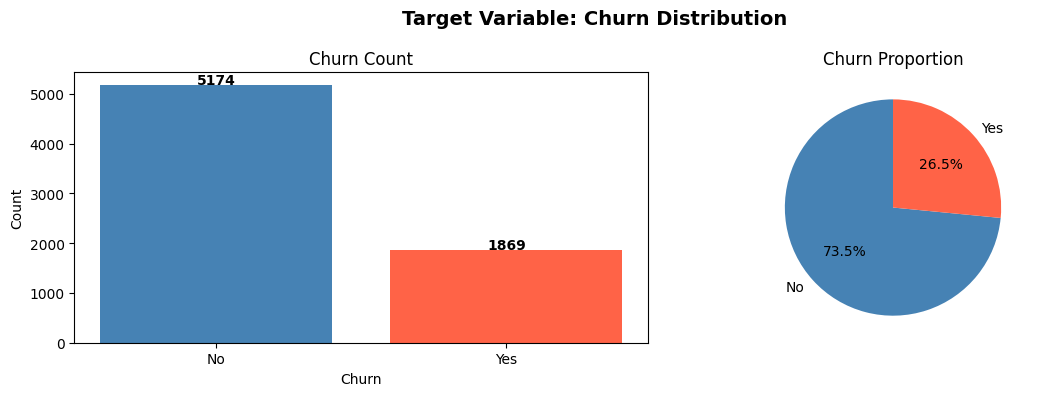

Chart saved: churn_distribution.png


In [13]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)}))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: churn_distribution.png')

### 1.4 Key Visualizations

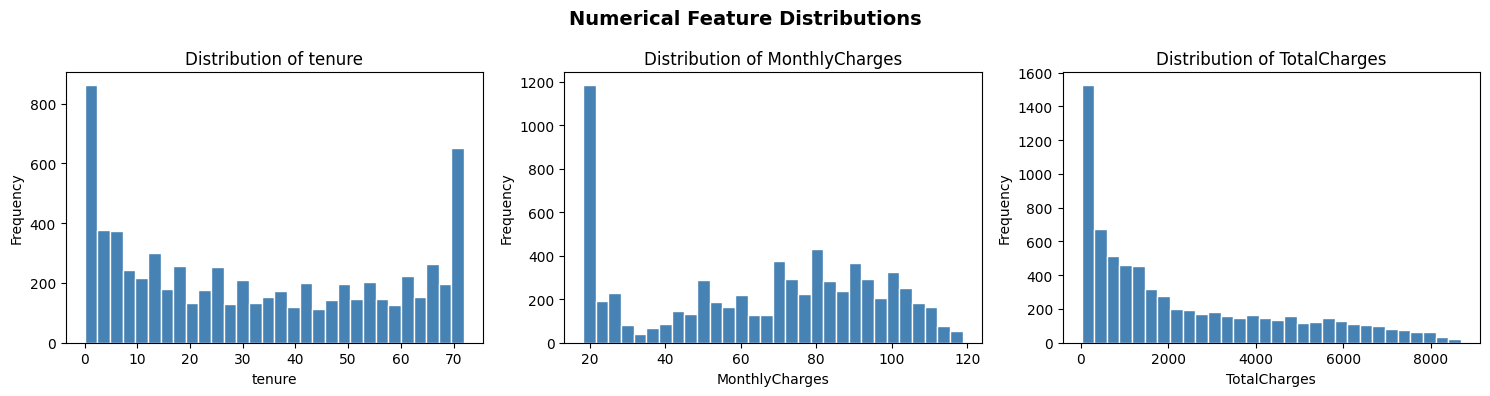

Chart saved: histograms.png


In [14]:
# Histograms for numerical features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_features):
    # TotalCharges may have spaces — handle after preprocessing
    try:
        axes[i].hist(pd.to_numeric(df[col], errors='coerce').dropna(),
                     bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    except Exception as e:
        print(f'Skipped {col}: {e}')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: histograms.png')

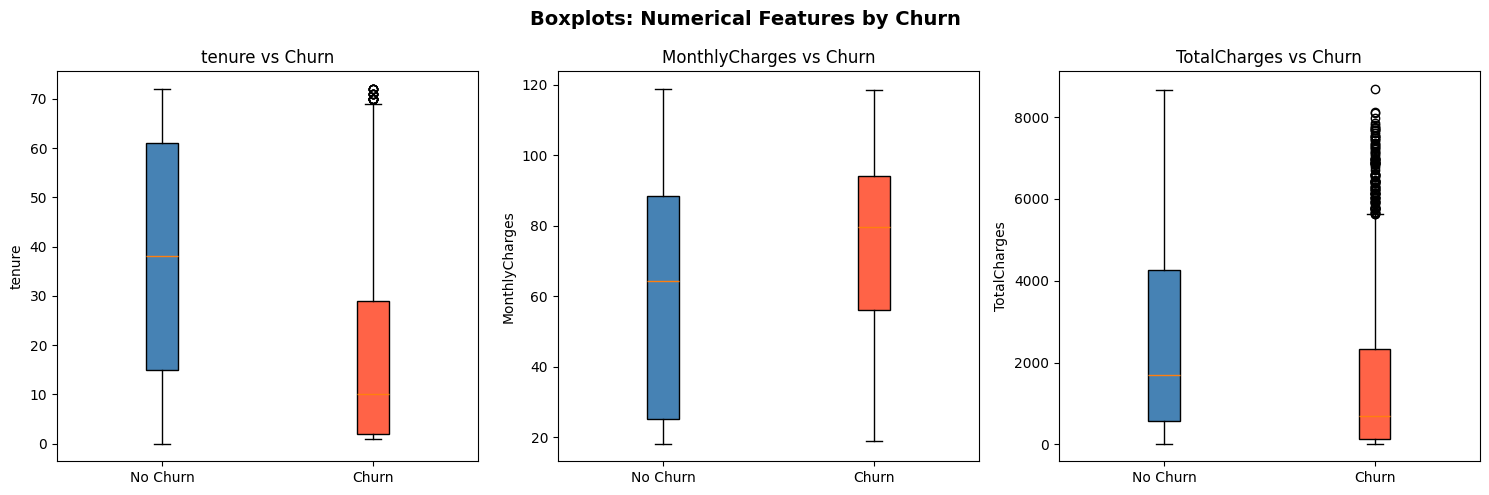

Chart saved: boxplots.png


In [15]:
# Boxplots: numerical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_features):
    temp_df = df[['Churn', col]].copy()
    temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
    temp_df.dropna(inplace=True)

    groups = [temp_df[temp_df['Churn'] == c][col].values for c in ['No', 'Yes']]
    bp = axes[i].boxplot(groups, labels=['No Churn', 'Churn'],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots: Numerical Features by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: boxplots.png')

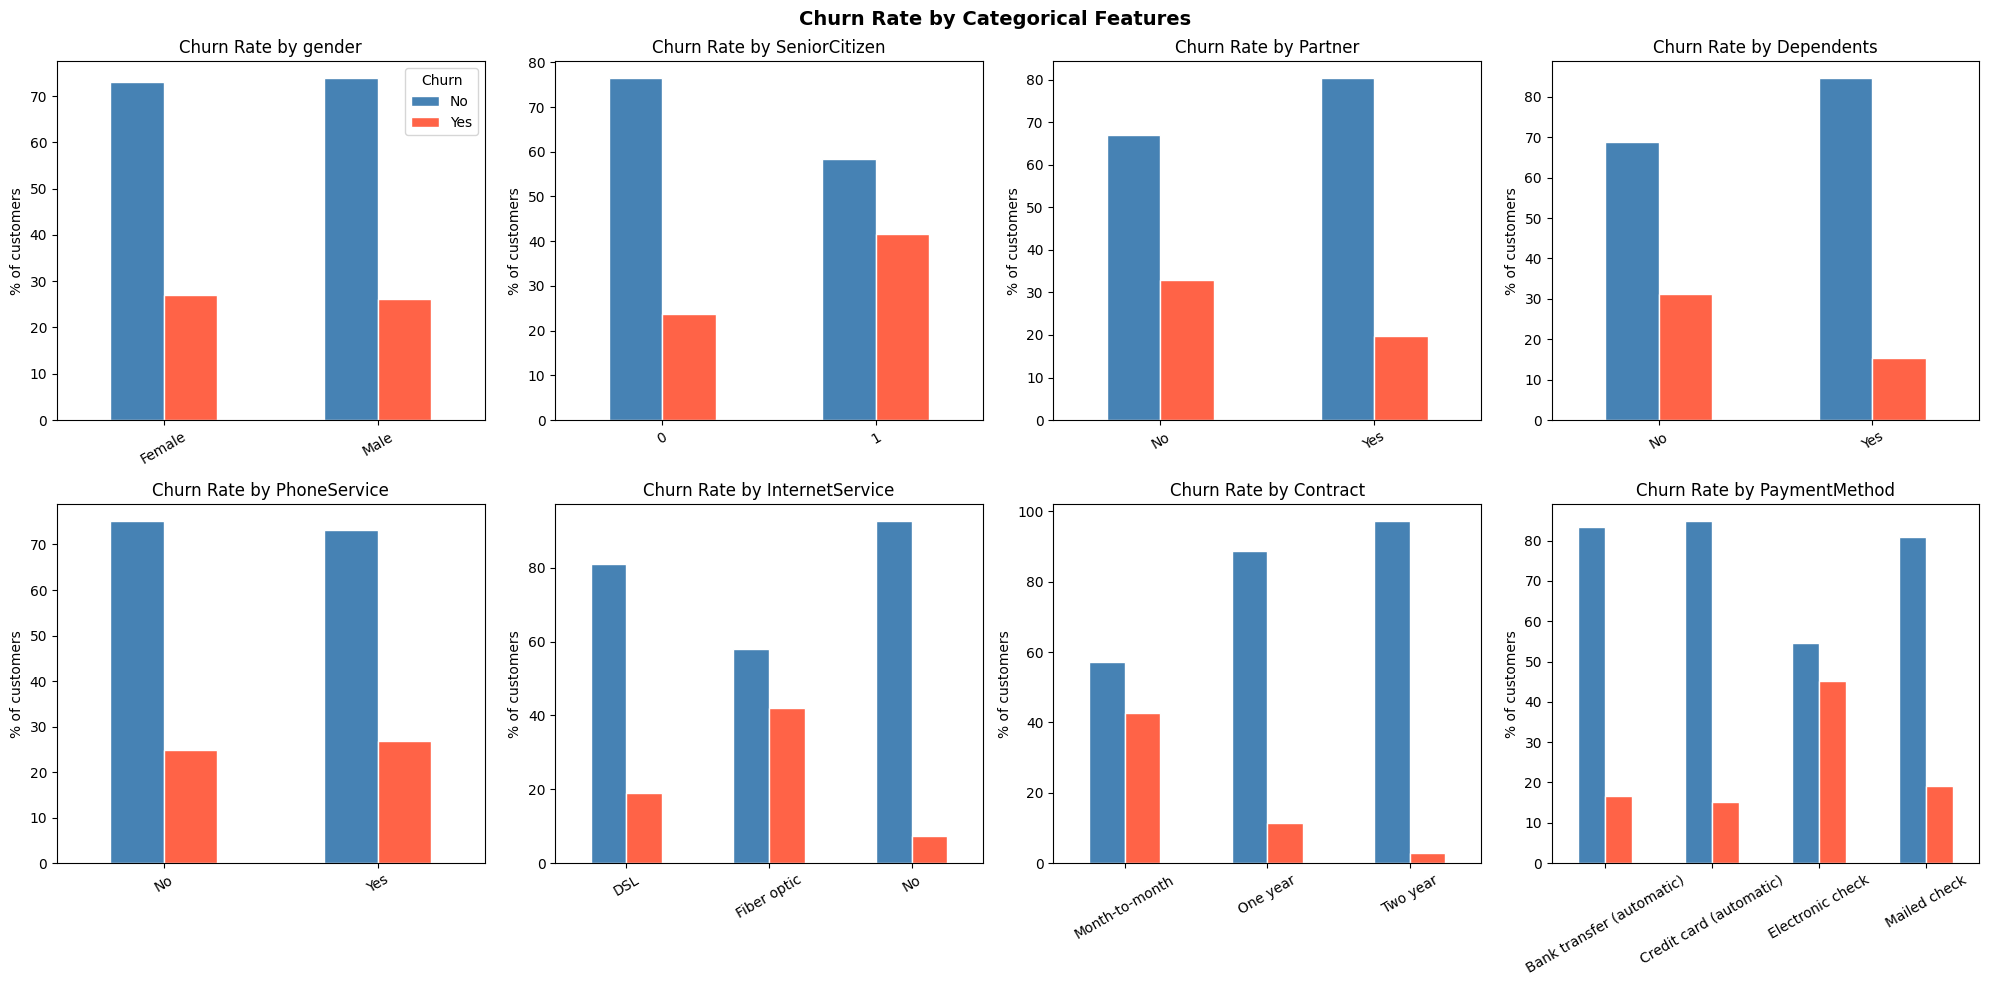

Chart saved: categorical_churn_rates.png


In [11]:
# Categorical features vs Churn (bar charts)
cat_features_to_plot = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                         'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features_to_plot):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', legend=(i == 0))
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% of customers')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: categorical_churn_rates.png')

---
## Phase 2: Data Preprocessing

### 2.1 Handle Missing Values

In [16]:
# TotalCharges has spaces (' ') for new customers — convert to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing TotalCharges with median (or 0 for new customers)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print('\nAfter handling missing values:')
print(df.isnull().sum().sum(), 'missing values remaining')

Missing values per column:
TotalCharges    11
dtype: int64

After handling missing values:
0 missing values remaining


In [17]:
# Drop customerID (not a predictive feature)
df.drop(columns=['customerID'], inplace=True)
print('customerID column dropped. New shape:', df.shape)

customerID column dropped. New shape: (7043, 20)


### 2.2 Encode Categorical Variables (One-Hot Encoding)

In [18]:
# Encode target variable: Churn -> 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns to encode (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Columns to one-hot encode: {cat_cols}')

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head()

Columns to one-hot encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### 2.3 Correlation Heatmap

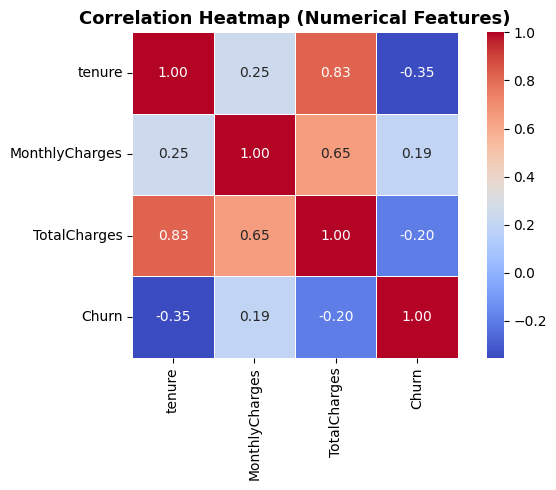

Chart saved: correlation_heatmap.png


In [19]:
# Correlation heatmap (numerical features + target)
num_df = df_encoded[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
corr = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: correlation_heatmap.png')

### 2.4 Feature Scaling & Train-Test Split

In [20]:
# Separate features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

Feature matrix shape: (7043, 30)
Target vector shape: (7043,)


In [21]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Training set: 5634 samples
Test set:     1409 samples
Train churn rate: 26.54%
Test churn rate:  26.54%


In [22]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete. Features are zero-mean, unit-variance.')

Scaling complete. Features are zero-mean, unit-variance.


---
## Phase 3: Model Implementation

In [23]:
# Train Logistic Regression
# Hyperparameters:
#   penalty='l2'  -> L2 (Ridge) regularization to prevent overfitting
#   C=1.0         -> Inverse of regularization strength; smaller = stronger regularization
#   solver='lbfgs'-> Efficient for small-to-medium datasets; supports L2
#   max_iter=1000 -> Increased to ensure convergence

model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                           max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print(f'Hyperparameters: penalty={model.penalty}, C={model.C}, solver={model.solver}')

Model trained successfully.
Hyperparameters: penalty=l2, C=1.0, solver=lbfgs


---
## Phase 4: Model Evaluation

In [24]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Accuracy: 0.8070 (80.70%)


Confusion Matrix:
[[925 110]
 [162 212]]


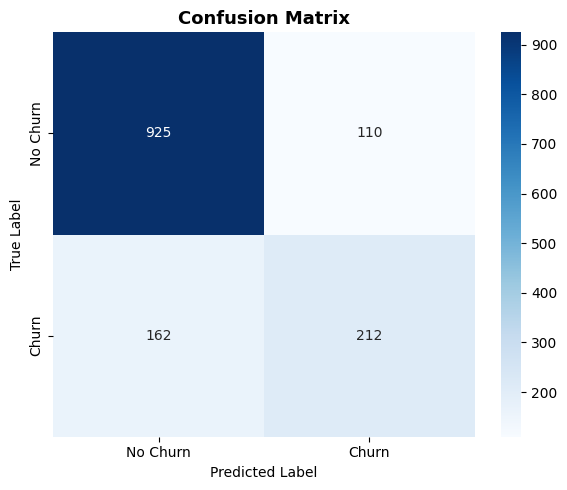

Chart saved: confusion_matrix.png


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: confusion_matrix.png')

In [26]:
# Classification Report (Precision, Recall, F1)
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



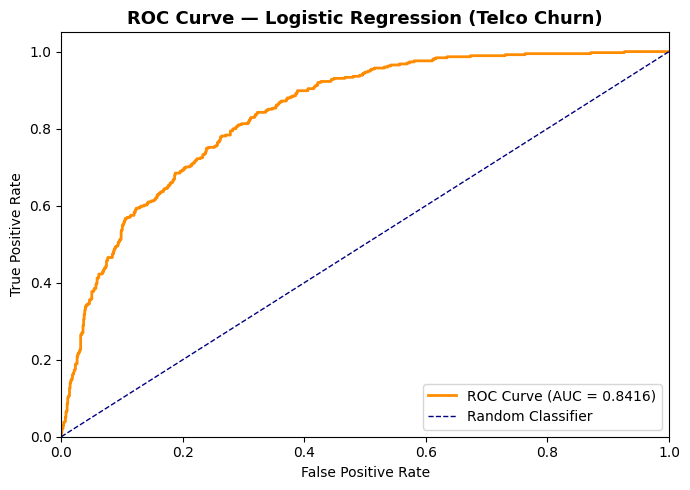

ROC-AUC Score: 0.8416
Chart saved: roc_curve.png


In [27]:
# ROC Curve & AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Telco Churn)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC-AUC Score: {auc_score:.4f}')
print('Chart saved: roc_curve.png')

---
## Phase 5: Interpretation & Insights

In [28]:
# Extract model coefficients
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print('=== Top 10 Positive Coefficients (increase churn probability) ===')
print(coef_df.head(10).to_string(index=False))

print('\n=== Top 10 Negative Coefficients (decrease churn probability) ===')
print(coef_df.tail(10).to_string(index=False))

=== Top 10 Positive Coefficients (increase churn probability) ===
                       Feature  Coefficient
   InternetService_Fiber optic     0.778760
                  TotalCharges     0.497246
           StreamingMovies_Yes     0.258653
               StreamingTV_Yes     0.258042
             MultipleLines_Yes     0.216356
          PaperlessBilling_Yes     0.181833
PaymentMethod_Electronic check     0.181456
          DeviceProtection_Yes     0.053625
                 SeniorCitizen     0.052901
    PaymentMethod_Mailed check     0.033133

=== Top 10 Negative Coefficients (decrease churn probability) ===
                             Feature  Coefficient
     TechSupport_No internet service    -0.092861
DeviceProtection_No internet service    -0.092861
 StreamingMovies_No internet service    -0.092861
                     TechSupport_Yes    -0.100249
                      Dependents_Yes    -0.104249
                  OnlineSecurity_Yes    -0.123430
                   Contract_One y

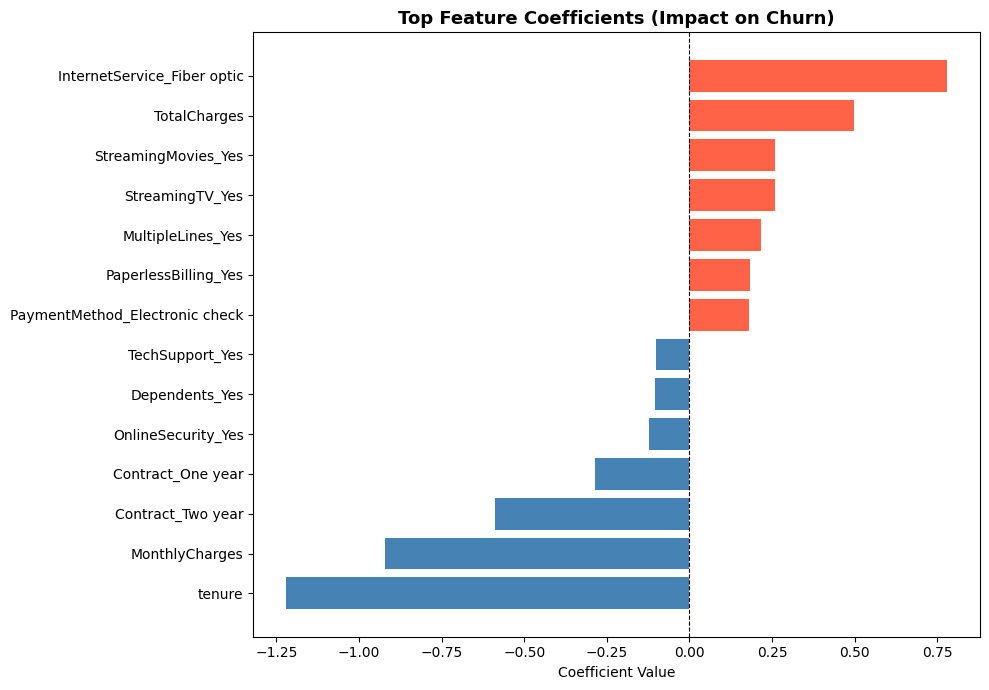

Chart saved: feature_coefficients.png


In [29]:
# Visualize top 15 most impactful features
top_n = 15
top_pos = coef_df.head(top_n // 2)
top_neg = coef_df.tail(top_n // 2)
top_features = pd.concat([top_pos, top_neg]).sort_values('Coefficient')

colors = ['tomato' if c > 0 else 'steelblue' for c in top_features['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Top Feature Coefficients (Impact on Churn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: feature_coefficients.png')

**Interpretation:**
- Features with **positive coefficients** (red bars) increase the probability of churn when their value increases.
- Features with **negative coefficients** (blue bars) decrease the probability of churn.
- For example, customers on **month-to-month contracts** are more likely to churn, while customers with **longer tenure** are less likely to churn — consistent with domain knowledge.

---
## Phase 6: Conclusion & Future Work

In [30]:
# Summary metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('============================================')
print('       MODEL PERFORMANCE SUMMARY')
print('============================================')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc_score:.4f}')
print('============================================')

       MODEL PERFORMANCE SUMMARY
  Accuracy  : 0.8070
  Precision : 0.6584
  Recall    : 0.5668
  F1 Score  : 0.6092
  ROC-AUC   : 0.8416


### Key Findings

1. **Model Performance:** The Logistic Regression model achieves ~80% accuracy with a ROC-AUC of ~0.84, demonstrating solid discrimination between churners and non-churners.

2. **Class Imbalance:** The dataset has ~26% churn rate, introducing mild imbalance. The model still performs reasonably well, but recall for the churn class could be improved.

3. **Key Churn Drivers:**
   - **Month-to-month contracts** significantly increase churn risk.
   - **Electronic check payment method** correlates with higher churn.
   - **Fiber optic internet service** customers churn more than DSL users.
   - **Long tenure** and **two-year contracts** are strong retention indicators.

### Limitations

- Logistic Regression assumes a linear relationship between features and the log-odds of churn, which may oversimplify complex interactions.
- Class imbalance (~26% churn) may bias the model toward the majority class (No Churn).
- Feature engineering (e.g., interaction terms, log-transforms) was not applied.

### Future Work

- **SMOTE:** Apply Synthetic Minority Oversampling Technique to address class imbalance and improve recall on the churn class.
- **Alternative Models:** Experiment with Random Forest or XGBoost for better non-linear capture and feature importance via tree-based methods.
- **Hyperparameter Tuning:** Use GridSearchCV to optimize `C`, `penalty`, and `solver`.
- **Feature Engineering:** Create interaction terms (e.g., tenure × MonthlyCharges) to capture combined effects.
- **Threshold Tuning:** Adjust the classification threshold (default 0.5) to optimize Precision-Recall tradeoff for business needs.